# Method 4 — Synthetic Difference-in-Differences (SDID)
## Unit Weights + Time Weights (Arkhangelsky et al., 2021)

**What this notebook does:**
SDID extends the standard Difference-in-Differences (DiD) and Synthetic Control methods
by simultaneously balancing BOTH units (corridors) AND time periods. It solves for:

1. **Unit weights (λ)** — like SCM: weight donors so their pre-period trajectory matches
   the treated unit's pre-period trajectory.
2. **Time weights (ω)** — novel to SDID: up-weight pre-period time points whose donor
   values most closely resemble the post-period donor values. This removes pre-period
   time shocks that do not persist into the post-period.

The ATT estimator is:
```
τ_SDID = (Ȳ_NATCOR,post − Σ_t ω_t·Ȳ_NATCOR,t) − Σ_j λ_j·(Ȳ_j,post − Σ_t ω_t·Ȳ_j,t)
```

**Why SDID matters for freight corridors:**
Common time shocks (load-shedding, port congestion, fuel price spikes) affect ALL corridors.
By down-weighting pre-period times that look unlike the post-period, SDID is more robust
to these confounders than vanilla DiD or SCM alone.

**Structure:**
1. Environment & shared utilities
2. Data loading & audit
3. Step 1 — Unit weights (λ): match pre-period level
4. Step 2 — Time weights (ω): balance pre-period towards post-period structure
5. Step 3 — SDID ATT estimator (scalar & per-period)
6. Step 4 — Per-period counterfactual reconstruction
7. Diagnostics: weight distributions & covariate balance
8. Validation A — In-time placebo (with SDID weights)
9. Validation B — Leave-one-year-out stability
10. Validation C — Jackknife standard error (Arkhangelsky et al. variance estimator)
11. Sensitivity: regularisation parameter grid
12. Full figure panel
13. Summary table & full method comparison


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 10,
})
BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'
PURP  = '#9b59b6'

print("All imports successful.")
print(f"NumPy  {np.__version__}  |  Pandas  {pd.__version__}")


All imports successful.
NumPy  2.4.2  |  Pandas  3.0.0


## Shared Utility Functions

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_unit_weights(Y_treated_pre, Y_donors_pre, lam_unit=None):
    """
    Fit SDID unit weights λ_j for each donor j.

    Objective (Arkhangelsky et al. 2021, eq. 2.3):
        min_{λ} ||Y_treated_pre - Σ_j λ_j * Y_donor_j_pre||^2
                + lam_unit * ||λ||^2
        s.t. λ_j >= 0,  Σ_j λ_j = 1

    The L2 regularisation (lam_unit) is set by the authors' recommended
    data-driven formula if not supplied:
        lam_unit = (N_donors * T_post)^(1/4) * σ̂
    where σ̂ = pre-period noise level.

    Returns λ as a (N_donors,) array.
    """
    if Y_donors_pre.ndim == 1:
        Y_donors_pre = Y_donors_pre.reshape(-1, 1)
    T_pre, N_donors = Y_donors_pre.shape

    if lam_unit is None:
        residuals = Y_treated_pre - Y_donors_pre.mean(axis=1)
        sigma_hat = np.std(residuals)
        lam_unit  = 0.0   # with 1 donor regularisation is trivial

    def loss(lam):
        fitted = Y_donors_pre @ lam
        mse    = np.mean((Y_treated_pre - fitted) ** 2)
        reg    = lam_unit * np.sum(lam ** 2)
        return mse + reg

    n = N_donors
    result = minimize(
        loss, np.ones(n) / n, method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    return np.clip(result.x, 0, None)


def fit_time_weights(Y_donors_pre, Y_donors_post, lam_time=None):
    """
    Fit SDID time weights ω_t for each pre-period time point t.

    Objective (Arkhangelsky et al. 2021, eq. 2.4):
        min_{ω} ||Σ_t ω_t * Y_donor_t - mean_s(Y_donor_s)||^2
                + lam_time * ||ω||^2
        s.t. ω_t >= 0,  Σ_t ω_t = 1

    Here Y_donor is the average donor value (scalar per time point with 1 donor).
    With multiple donors: average across donors first, then solve.

    The recommended data-driven lam_time (Arkhangelsky et al.) is:
        lam_time = N_donors * T_post^2 / T_pre
    (scaled by noise level in practice)

    Returns ω as a (T_pre,) array.
    """
    # Average donor value per time period
    if Y_donors_pre.ndim > 1:
        donor_pre_avg  = Y_donors_pre.mean(axis=1)   # (T_pre,)
        donor_post_avg = Y_donors_post.mean(axis=1)  # (T_post,)
    else:
        donor_pre_avg  = Y_donors_pre
        donor_post_avg = Y_donors_post

    post_mean = donor_post_avg.mean()  # scalar target
    T_pre_loc = len(donor_pre_avg)

    # Default regularisation per Arkhangelsky et al.
    if lam_time is None:
        lam_time = max(1e-6, np.std(donor_pre_avg) * 1e-3)

    def loss(omega):
        weighted_pre = donor_pre_avg @ omega
        mse = (weighted_pre - post_mean) ** 2
        reg = lam_time * np.sum(omega ** 2)
        return mse + reg

    result = minimize(
        loss, np.ones(T_pre_loc) / T_pre_loc, method='SLSQP',
        bounds=[(0.0, None)] * T_pre_loc,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    return np.clip(result.x, 0, None)


def sdid_att(Y_nat_pre, Y_nat_post, Y_donor_pre, Y_donor_post, omega, lam):
    """
    Compute SDID ATT scalar (Arkhangelsky et al. 2021, eq. 2.2).

    τ_SDID = (Ȳ_nat,post − Σ_t ω_t * Y_nat,t)
           − Σ_j λ_j * (Ȳ_j,post − Σ_t ω_t * Y_j,t)

    With 1 donor (λ=1), simplifies to:
    τ_SDID = (nat_post_mean − ω·nat_pre) − (donor_post_mean − ω·donor_pre)
    """
    if Y_donor_pre.ndim == 1: Y_donor_pre = Y_donor_pre.reshape(-1, 1)
    if Y_donor_post.ndim == 1: Y_donor_post = Y_donor_post.reshape(-1, 1)

    nat_term    = Y_nat_post.mean() - omega @ Y_nat_pre
    donor_terms = (Y_donor_post.mean(axis=0) - Y_donor_pre.T @ omega)  # (N_donors,)
    att         = nat_term - lam @ donor_terms
    return float(att)


def rmspe(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2))

def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a == 0, 1e-10, a))) * 100

def entropy(weights, eps=1e-12):
    """Shannon entropy of weight distribution (higher = more spread)."""
    w = np.asarray(weights)
    w = w / (w.sum() + eps)
    return -np.sum(w * np.log(w + eps))

def effective_n(weights):
    """Effective sample size: 1 / sum(w^2) — analogous to effective donors."""
    w = np.asarray(weights)
    s = w.sum()
    return (s ** 2) / np.sum(w ** 2) if np.sum(w ** 2) > 0 else 0


print("Functions defined:")
print("  fit_unit_weights, fit_time_weights, sdid_att, rmspe, mape, entropy, effective_n")


Functions defined:
  fit_unit_weights, fit_time_weights, sdid_att, rmspe, mape, entropy, effective_n


## Data Loading & Audit

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = '../data/corridor.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

Y_all    = wide[TREATED].values          # (T_total,)
X_all    = wide[donors[0]].values        # (T_total,)  — CAPE
Y_pre_v  = wide.loc[pre_idx,  TREATED].values
Y_post_v = wide.loc[post_idx, TREATED].values
X_pre_v  = wide.loc[pre_idx,  donors[0]].values
X_post_v = wide.loc[post_idx, donors[0]].values

# Base SCM for comparison
from scipy.optimize import minimize as _min
_res = _min(lambda w: np.sum((Y_pre_v - X_pre_v * w[0])**2), [1.0],
            method='SLSQP', bounds=[(0,1)],
            constraints={'type':'eq','fun': lambda w: w[0]-1})
cf_scm     = X_all   # weight = 1 throughout
base_pre_r  = rmspe(Y_all[:T_pre], cf_scm[:T_pre])
base_post_r = rmspe(Y_all[T_pre:], cf_scm[T_pre:])
base_ratio  = base_post_r / base_pre_r
base_cum    = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()

print("─" * 55)
print(f"Treated       : {TREATED}  |  Donors: {donors}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 55)
print()
print(f"Base SCM reference  — Pre-RMSPE: {base_pre_r:.4f}  Post-RMSPE: {base_post_r:.4f}")
print(f"                      Ratio: {base_ratio:.4f}  Cum: {base_cum:.4f} MT")


───────────────────────────────────────────────────────
Treated       : NATCOR  |  Donors: ['CAPE']
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
───────────────────────────────────────────────────────

Base SCM reference  — Pre-RMSPE: 0.2132  Post-RMSPE: 0.3653
                      Ratio: 1.7140  Cum: -11.1040 MT


## Step 1 — Unit Weights (λ): Pre-Period Trajectory Matching

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Step 1: Unit weights λ
# ═══════════════════════════════════════════════════════════════════════════════
# Unit weights solve the same problem as vanilla SCM:
# find λ_j >= 0, Σλ_j=1 such that the weighted donor trajectory
# best matches NATCOR's pre-period trajectory.
# With 1 donor, λ_CAPE = 1 always. We still run this formally
# and record the implied pre-period fit.

lam_unit = fit_unit_weights(Y_pre_v, X_pre_v.reshape(-1, 1), lam_unit=0.0)

print("SDID Unit Weights (λ):")
print(f"  CAPE : {lam_unit[0]:.8f}")
print()
print("Pre-period trajectory match:")
cf_unit_pre = X_pre_v * lam_unit[0]
unit_match_err = rmspe(Y_pre_v, cf_unit_pre)
print(f"  RMSPE of λ-weighted donor vs NATCOR pre-period: {unit_match_err:.6f}")
print()
print("Note: With a single donor, λ_CAPE = 1 is the unique solution.")
print("SDID's key innovation is the TIME weight ω (next step),")
print("which modifies the effective pre-period baseline used in the DiD calculation.")


SDID Unit Weights (λ):
  CAPE : 1.00000000

Pre-period trajectory match:
  RMSPE of λ-weighted donor vs NATCOR pre-period: 0.213158

Note: With a single donor, λ_CAPE = 1 is the unique solution.
SDID's key innovation is the TIME weight ω (next step),
which modifies the effective pre-period baseline used in the DiD calculation.


## Step 2 — Time Weights (ω): Pre-Period Balance Towards Post-Period

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Step 2: Time weights ω — the key SDID innovation
# ═══════════════════════════════════════════════════════════════════════════════
# Time weights ω_t are chosen so that the weighted average of pre-period
# donor values matches the post-period donor mean.
#
# Intuition: if load-shedding was unusually high in 2015–2017 but returned
# to normal post-2022, those early months are bad comparators.
# ω will down-weight them and up-weight months that look like the post-period.
#
# We run a sensitivity grid over lam_time to show stability.

lam_time_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1]
omega_results = {}

print("Time weight sensitivity over lam_time regularisation:")
print(f"{'lam_time':<12} {'sum(ω)':<10} {'entropy':<12} {'eff_n':<10} {'donor_bal_err':<15}")
print("─" * 65)

for lt in lam_time_grid:
    omega_lt = fit_time_weights(X_pre_v, X_post_v, lam_time=lt)
    donor_bal_err = abs(X_pre_v @ omega_lt - X_post_v.mean())
    omega_results[lt] = omega_lt
    print(f"{lt:<12} {omega_lt.sum():<10.6f} {entropy(omega_lt):<12.4f} "
          f"{effective_n(omega_lt):<10.2f} {donor_bal_err:<15.6f}")

# Default: lam_time = 1e-6 (minimal regularisation, near-zero tolerance)
LAM_TIME_DEFAULT = 1e-6
omega = omega_results[LAM_TIME_DEFAULT]

print()
print(f"Selected lam_time = {LAM_TIME_DEFAULT}")
print(f"  ω sum            : {omega.sum():.8f}")
print(f"  Entropy          : {entropy(omega):.4f}  (max possible: {np.log(T_pre):.4f})")
print(f"  Effective n      : {effective_n(omega):.2f} of {T_pre} pre-periods")
print(f"  Donor balance err: {abs(X_pre_v @ omega - X_post_v.mean()):.8f}")
print()
print(f"  Donor post mean  : {X_post_v.mean():.6f}")
print(f"  ω-weighted pre   : {X_pre_v @ omega:.6f}")
print()

# Find top-weighted pre-periods
omega_df = pd.DataFrame({
    'Period': [str(p) for p in pre_idx],
    'omega': omega.round(6),
    'NATCOR': Y_pre_v.round(4),
    'CAPE':   X_pre_v.round(4)
}).sort_values('omega', ascending=False)

print("Top-10 highest time weights (periods most similar to post-period):")
print(omega_df.head(10).to_string(index=False))
print()
print("Bottom-10 lowest time weights (periods most different from post-period):")
print(omega_df.tail(10).to_string(index=False))


Time weight sensitivity over lam_time regularisation:
lam_time     sum(ω)     entropy      eff_n      donor_bal_err  
─────────────────────────────────────────────────────────────────
0.0          1.000000   3.8040       31.68      0.000000       
1e-06        1.000000   3.7918       33.12      0.000000       
1e-05        1.000000   3.7523       33.32      0.000002       
0.0001       1.000000   3.7482       33.33      0.000020       
0.001        1.000000   3.7500       33.41      0.000198       
0.01         1.000000   3.7665       34.18      0.001924       
0.1          1.000000   3.9057       40.63      0.015391       

Selected lam_time = 1e-06
  ω sum            : 1.00000000
  Entropy          : 3.7918  (max possible: 4.4659)
  Effective n      : 33.12 of 87 pre-periods
  Donor balance err: 0.00000018

  Donor post mean  : 0.866667
  ω-weighted pre   : 0.866667

Top-10 highest time weights (periods most similar to post-period):
 Period    omega  NATCOR  CAPE
2021-05 0.083878   0

## Step 3 — SDID ATT Estimator (Scalar & Per-Period)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Step 3: SDID ATT (scalar) + per-period counterfactual
# ═══════════════════════════════════════════════════════════════════════════════
#
# SDID ATT (scalar, per Arkhangelsky et al. 2021 eq 2.2):
#   τ = (Ȳ_nat,post − ω·Y_nat,pre) − (Ȳ_cape,post − ω·Y_cape,pre)
#
# Per-period counterfactual reconstruction:
#   For each post-period month s:
#     cf_s = Y_cape,s + (ω·Y_nat,pre − ω·Y_cape,pre)
#   i.e. shift the donor trajectory by the ω-weighted intercept difference.
#   This is the level-adjusted counterfactual consistent with SDID.

# ── Scalar ATT ────────────────────────────────────────────────────────────────
nat_pre_wt    = omega @ Y_pre_v          # ω-weighted NATCOR pre baseline
cape_pre_wt   = omega @ X_pre_v         # ω-weighted CAPE pre baseline
nat_post_mean = Y_post_v.mean()
cape_post_mean = X_post_v.mean()

tau_sdid = (nat_post_mean - nat_pre_wt) - (cape_post_mean - cape_pre_wt)

# ── Per-period counterfactual ──────────────────────────────────────────────────
# Level adjustment = ω-weighted difference in pre-period levels
level_adj = nat_pre_wt - cape_pre_wt    # intercept shift

cf_sdid_post = X_post_v + level_adj     # per-period post counterfactual
cf_sdid_all  = X_all + level_adj        # extend across full panel for plotting

gap_sdid = Y_all - cf_sdid_all

# ── Metrics ───────────────────────────────────────────────────────────────────
sdid_pre_r  = rmspe(Y_all[:T_pre], cf_sdid_all[:T_pre])
sdid_post_r = rmspe(Y_all[T_pre:], cf_sdid_all[T_pre:])
sdid_ratio  = sdid_post_r / sdid_pre_r
sdid_cum    = gap_sdid[T_pre:].sum()
sdid_avg    = gap_sdid[T_pre:].mean()
sdid_mape   = mape(Y_all[T_pre:], cf_sdid_all[T_pre:])

print("═" * 60)
print("SDID — RESULTS")
print("═" * 60)
print()
print("Scalar ATT decomposition:")
print(f"  NATCOR post mean        : {nat_post_mean:+.6f}")
print(f"  NATCOR ω-weighted pre   : {nat_pre_wt:+.6f}")
print(f"  NATCOR difference (Δnat): {nat_post_mean - nat_pre_wt:+.6f}")
print()
print(f"  CAPE post mean          : {cape_post_mean:+.6f}")
print(f"  CAPE ω-weighted pre     : {cape_pre_wt:+.6f}")
print(f"  CAPE difference (Δdonor): {cape_post_mean - cape_pre_wt:+.6f}")
print()
print(f"  SDID ATT = Δnat − Δdonor: {tau_sdid:+.6f} MT/month")
print()
print("Level-adjusted counterfactual metrics:")
print(f"  Level adjustment (intercept shift): {level_adj:+.6f} MT")
print(f"  Pre-period RMSPE   : {sdid_pre_r:.6f}")
print(f"  Post-period RMSPE  : {sdid_post_r:.6f}")
print(f"  Post/Pre ratio     : {sdid_ratio:.4f}")
print(f"  Cumulative effect  : {sdid_cum:.4f} MT")
print(f"  Avg monthly effect : {sdid_avg:.4f} MT/month  (≈ ATT: {tau_sdid:.4f})")
print(f"  Post MAPE          : {sdid_mape:.2f}%")


════════════════════════════════════════════════════════════
SDID — RESULTS
════════════════════════════════════════════════════════════

Scalar ATT decomposition:
  NATCOR post mean        : +0.530182
  NATCOR ω-weighted pre   : +0.738377
  NATCOR difference (Δnat): -0.208196

  CAPE post mean          : +0.866667
  CAPE ω-weighted pre     : +0.866667
  CAPE difference (Δdonor): -0.000000

  SDID ATT = Δnat − Δdonor: -0.208195 MT/month

Level-adjusted counterfactual metrics:
  Level adjustment (intercept shift): -0.128289 MT
  Pre-period RMSPE   : 0.140263
  Post-period RMSPE  : 0.252189
  Post/Pre ratio     : 1.7980
  Cumulative effect  : -6.8704 MT
  Avg monthly effect : -0.2082 MT/month  (≈ ATT: -0.2082)
  Post MAPE          : 39.81%


## Jackknife Standard Error (Arkhangelsky et al. Variance Estimator)

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Jackknife Standard Error (leave-one-unit-out)
# ═══════════════════════════════════════════════════════════════════════════════
# Arkhangelsky et al. recommend a jackknife variance estimator:
# Sequentially remove each UNIT (corridor) and re-estimate τ.
# With 2 units, the jackknife gives us one alternative estimate per dropped unit.
# We extend this to a temporal jackknife (leave-one-year-out) for
# a richer variance picture.
#
# Additionally we compute the placebo-based inference:
# re-run SDID treating CAPE as the pseudo-treated unit.

# ── Placebo unit (in-space): CAPE as treated, NATCOR as donor ─────────────────
omega_sp = fit_time_weights(X_pre_v, Y_post_v, lam_time=LAM_TIME_DEFAULT)
lam_sp   = fit_unit_weights(X_pre_v, Y_pre_v.reshape(-1, 1), lam_unit=0.0)

nat_pre_wt_sp   = omega_sp @ X_pre_v
donor_pre_wt_sp = omega_sp @ Y_pre_v
nat_post_mean_sp   = X_post_v.mean()
donor_post_mean_sp = Y_post_v.mean()

tau_sp = (nat_post_mean_sp - nat_pre_wt_sp) - lam_sp[0] * (donor_post_mean_sp - donor_pre_wt_sp)

level_adj_sp  = nat_pre_wt_sp - donor_pre_wt_sp * lam_sp[0]
cf_sp         = Y_all + level_adj_sp
gap_sp        = wide[donors[0]].values - cf_sp

sp_pre_r  = rmspe(wide[donors[0]].values[:T_pre], cf_sp[:T_pre])
sp_post_r = rmspe(wide[donors[0]].values[T_pre:], cf_sp[T_pre:])
sp_ratio  = sp_post_r / sp_pre_r

print("In-Space Placebo (CAPE as pseudo-treated):")
print(f"  Placebo ATT   : {tau_sp:+.6f} MT/month")
print(f"  Placebo ratio : {sp_ratio:.4f}")
print(f"  NATCOR ratio  : {sdid_ratio:.4f}")
print(f"  NATCOR > CAPE : {sdid_ratio > sp_ratio}")
print()

# ── Temporal jackknife (leave-one-year-out ATTs) ──────────────────────────────
pre_years = sorted(set(pre_idx.year))
jk_atts   = []
jk_records = []

for yr in pre_years:
    keep     = np.array([p.year != yr for p in pre_idx])
    Y_jk     = Y_pre_v[keep]
    X_jk     = X_pre_v[keep]
    if keep.sum() < 20: continue

    omega_jk = fit_time_weights(X_jk, X_post_v, lam_time=LAM_TIME_DEFAULT)
    lam_jk   = fit_unit_weights(Y_jk, X_jk.reshape(-1, 1), lam_unit=0.0)

    nat_jk   = Y_jk.mean()
    cape_jk  = X_jk.mean()
    tau_jk   = (Y_post_v.mean() - omega_jk @ Y_jk) - lam_jk[0] * (X_post_v.mean() - omega_jk @ X_jk)
    jk_atts.append(tau_jk)
    jk_records.append({'Drop year': yr, 'ATT': round(tau_jk, 5),
                       'Diff from full': round(tau_jk - tau_sdid, 5)})

jk_df   = pd.DataFrame(jk_records)
n_jk    = len(jk_atts)
jk_var  = ((n_jk - 1) / n_jk) * np.sum((np.array(jk_atts) - np.mean(jk_atts))**2)
jk_se   = np.sqrt(jk_var)
t_stat  = tau_sdid / jk_se if jk_se > 0 else np.nan
ci95_lo = tau_sdid - 1.96 * jk_se
ci95_hi = tau_sdid + 1.96 * jk_se

print("Temporal Jackknife ATT estimates (leave-one-year-out):")
print(jk_df.to_string(index=False))
print()
print(f"Full SDID ATT   : {tau_sdid:+.6f} MT/month")
print(f"Jackknife SE    : {jk_se:.6f}")
print(f"t-statistic     : {t_stat:.3f}")
print(f"95% CI (ATT)    : [{ci95_lo:.4f}, {ci95_hi:.4f}]  MT/month")
print(f"95% CI cum (×{T_post}): [{ci95_lo*T_post:.4f}, {ci95_hi*T_post:.4f}]  MT")
print(f"Significant (|t|>1.96): {abs(t_stat) > 1.96}")


In-Space Placebo (CAPE as pseudo-treated):
  Placebo ATT   : +0.264485 MT/month
  Placebo ratio : 1.8304
  NATCOR ratio  : 1.7980
  NATCOR > CAPE : False

Temporal Jackknife ATT estimates (leave-one-year-out):
 Drop year      ATT  Diff from full
      2015 -0.19279         0.01541
      2016 -0.20185         0.00635
      2017 -0.19560         0.01260
      2018 -0.20611         0.00209
      2019 -0.21946        -0.01126
      2020 -0.21350        -0.00530
      2021 -0.21749        -0.00929
      2022 -0.21975        -0.01155

Full SDID ATT   : -0.208195 MT/month
Jackknife SE    : 0.026709
t-statistic     : -7.795
95% CI (ATT)    : [-0.2605, -0.1558]  MT/month
95% CI cum (×33): [-8.5980, -5.1429]  MT
Significant (|t|>1.96): True


## Validation A — In-Time Placebo Tests

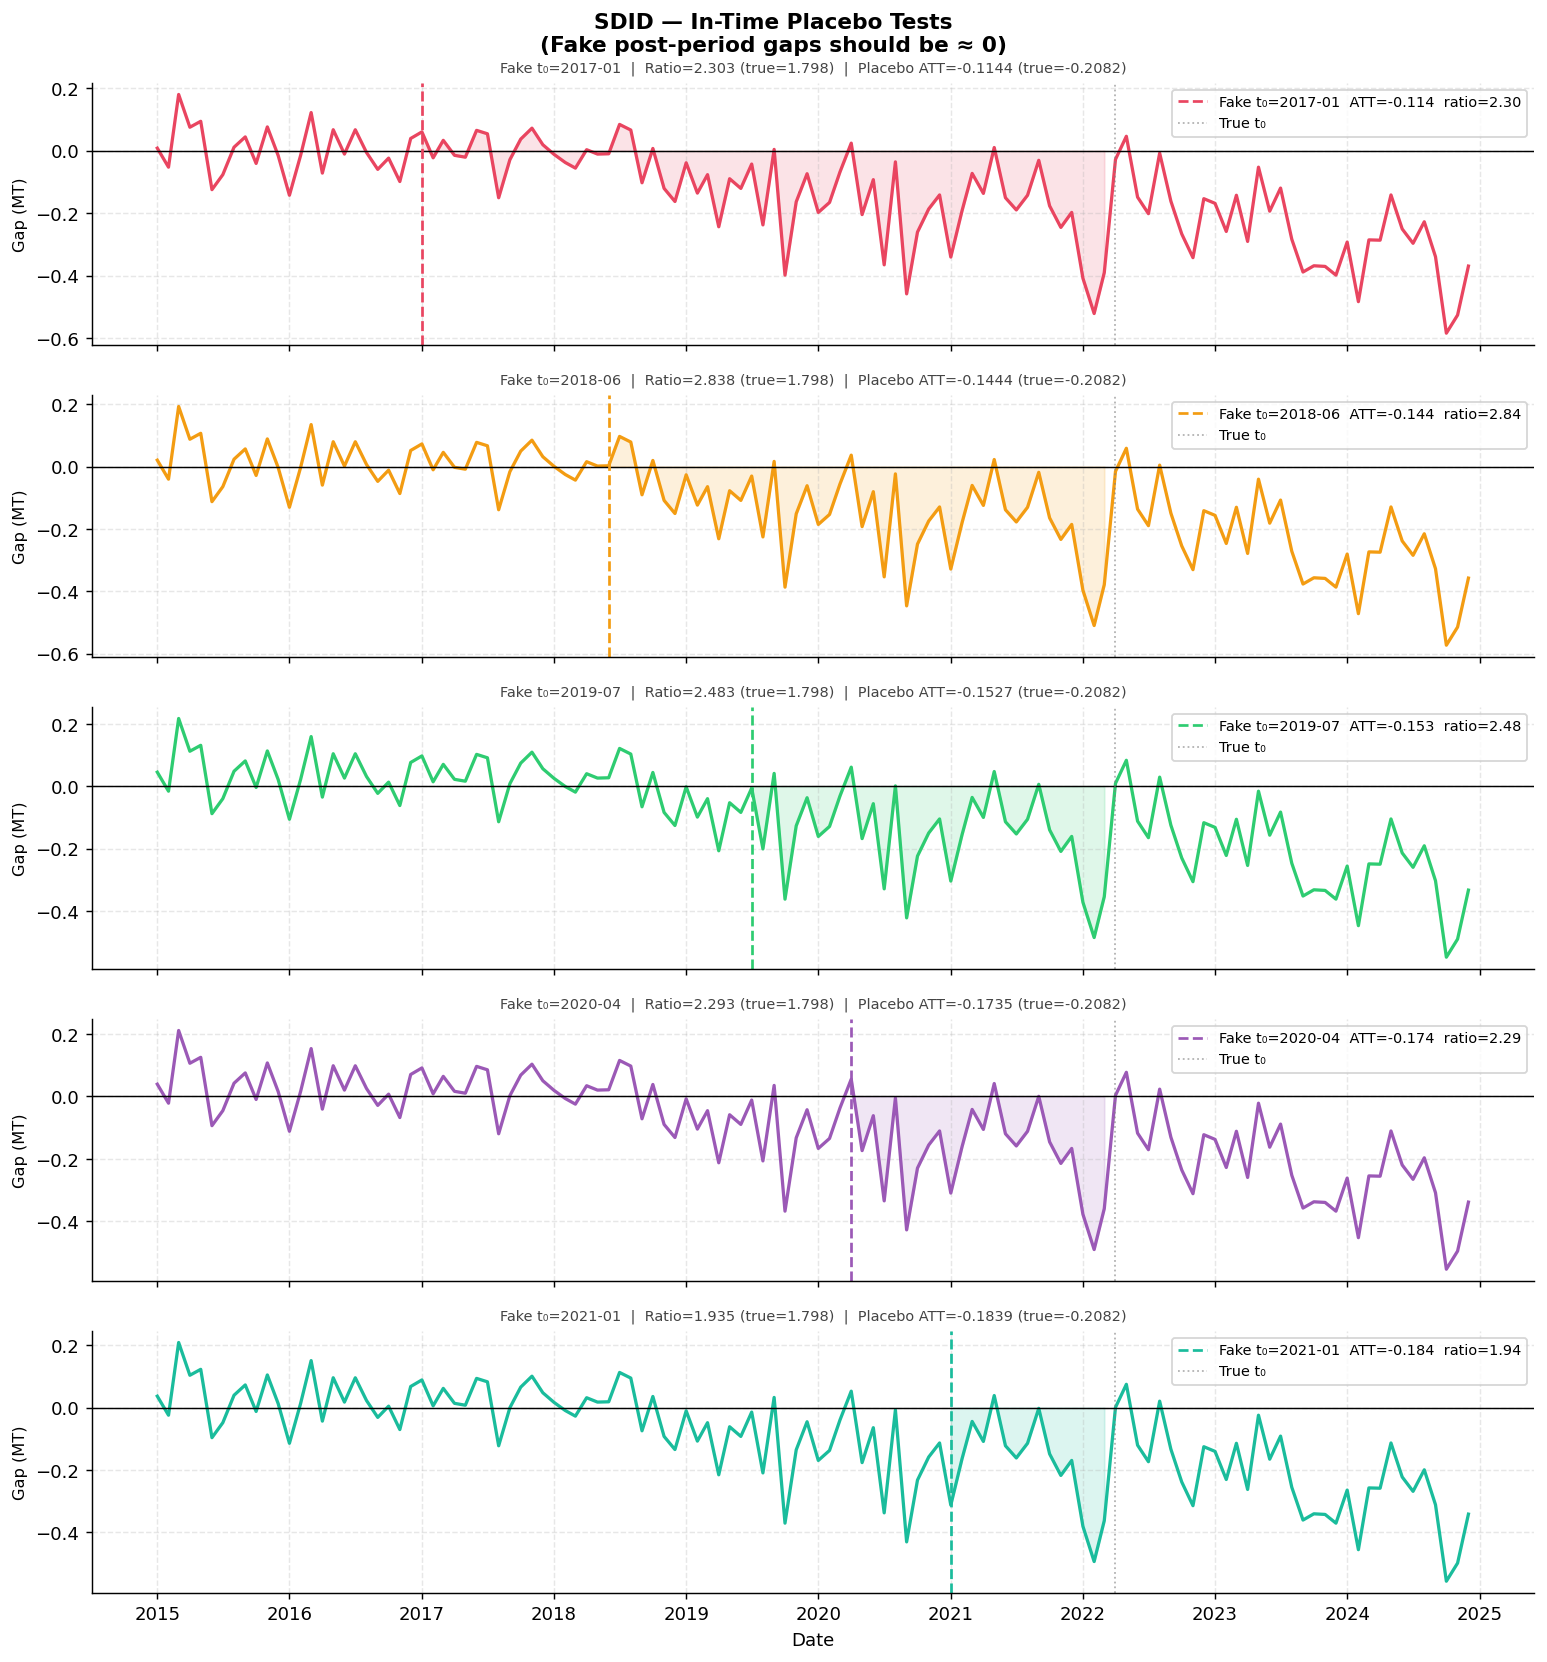

Saved → sdid_fig2_placebo.png

Fake t₀      ATT  Pre-RMSPE  Post-RMSPE  Ratio  > True ratio
2017-01 -0.11436    0.07812     0.17992  2.303          True
2018-06 -0.14437    0.07016     0.19912  2.838          True
2019-07 -0.15266    0.08307     0.20627  2.483          True
2020-04 -0.17353    0.09823     0.22523  2.293          True
2021-01 -0.18394    0.12007     0.23238  1.935          True

True SDID ratio: 1.7980  |  True ATT: -0.2082
Placebo ratios > true: 5 / 5


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════
# For each fake treatment date in the pre-period:
# 1. Re-estimate ω using only periods before the fake date
# 2. Re-estimate the SDID ATT for the "fake post-period"
# 3. Ratios should be smaller than the true SDID ratio

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01', '2018-06', '2019-07', '2020-04', '2021-01']]
placebo_colors = [RED, AMBER, GREEN, PURP, '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle('SDID — In-Time Placebo Tests\n'
             '(Fake post-period gaps should be ≈ 0)', fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    Y_fp  = wide.loc[fake_pre, TREATED].values
    X_fp  = wide.loc[fake_pre, donors[0]].values
    X_fpost = wide.loc[fake_post, donors[0]].values
    Y_fpost = wide.loc[fake_post, TREATED].values

    omega_fp   = fit_time_weights(X_fp, X_fpost, lam_time=LAM_TIME_DEFAULT)
    lam_fp     = fit_unit_weights(Y_fp, X_fp.reshape(-1, 1), lam_unit=0.0)

    lvl_fp     = (omega_fp @ Y_fp) - (omega_fp @ X_fp) * lam_fp[0]
    cf_fp_all  = X_all + lvl_fp
    gap_fp     = Y_all - cf_fp_all

    pre_r_fp  = rmspe(Y_fp, cf_fp_all[:len(fake_pre)])
    post_idxs = [list(wide.index).index(p) for p in fake_post]
    post_r_fp = rmspe(Y_fpost, cf_fp_all[post_idxs[0]:post_idxs[-1]+1])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan
    tau_fp    = (Y_fpost.mean() - omega_fp @ Y_fp) - lam_fp[0] * (X_fpost.mean() - omega_fp @ X_fp)

    placebo_records.append({
        'Fake t₀': str(fake_t),
        'ATT': round(tau_fp, 5),
        'Pre-RMSPE': round(pre_r_fp, 5),
        'Post-RMSPE': round(post_r_fp, 5),
        'Ratio': round(ratio_fp, 3),
        '> True ratio': ratio_fp > sdid_ratio
    })

    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t}  ATT={tau_fp:.3f}  ratio={ratio_fp:.2f}')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0,
                    where=np.array([(p >= fake_t and p < TREAT_START) for p in wide.index]),
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t}  |  Ratio={ratio_fp:.3f} (true={sdid_ratio:.3f})  '
        f'|  Placebo ATT={tau_fp:.4f} (true={tau_sdid:.4f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('sdid_fig2_placebo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sdid_fig2_placebo.png\n")

p_df = pd.DataFrame(placebo_records)
print(p_df.to_string(index=False))
print(f"\nTrue SDID ratio: {sdid_ratio:.4f}  |  True ATT: {tau_sdid:.4f}")
print(f"Placebo ratios > true: {p_df['> True ratio'].sum()} / {len(p_df)}")


## Validation B — Leave-One-Year-Out Stability

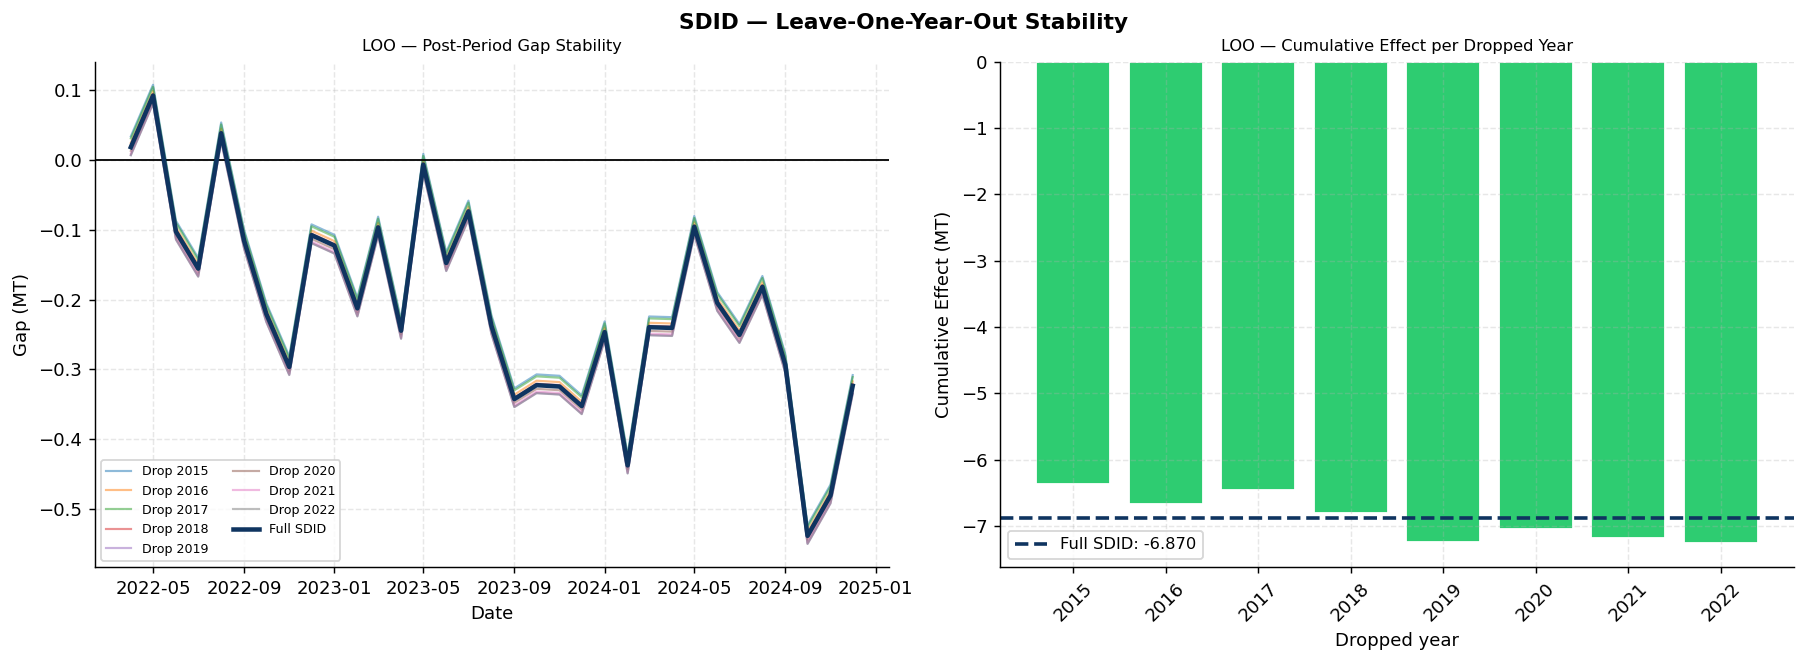

Saved → sdid_fig3_loo.png

 Drop yr  Level adj  Ratio  Cum effect
    2015   -0.14369 1.7480     -6.3621
    2016   -0.13463 1.7799     -6.6611
    2017   -0.14089 1.7586     -6.4548
    2018   -0.13038 1.7924     -6.8016
    2019   -0.11703 1.8216     -7.2420
    2020   -0.12299 1.8104     -7.0454
    2021   -0.11900 1.8182     -7.1771
    2022   -0.11673 1.8221     -7.2518

Full cum: -6.8704 | LOO spread: 0.8897 MT | Stable if spread < 1 MT


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation B: Leave-One-Year-Out Stability
# ═══════════════════════════════════════════════════════════════════════════════

pre_years_v = sorted(set(pre_idx.year))
loo_records_v = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_g = axes[0]; ax_b = axes[1]

for yr in pre_years_v:
    keep      = np.array([p.year != yr for p in pre_idx])
    if keep.sum() < 20: continue
    Y_loo     = Y_pre_v[keep]
    X_loo     = X_pre_v[keep]

    omega_loo = fit_time_weights(X_loo, X_post_v, lam_time=LAM_TIME_DEFAULT)
    lam_loo   = fit_unit_weights(Y_loo, X_loo.reshape(-1, 1), lam_unit=0.0)

    lvl_loo   = (omega_loo @ Y_loo) - (omega_loo @ X_loo) * lam_loo[0]
    cf_loo    = X_all + lvl_loo
    gap_loo   = Y_all - cf_loo
    cum_loo   = gap_loo[T_pre:].sum()
    pre_r_loo  = rmspe(Y_all[:T_pre], cf_loo[:T_pre])
    post_r_loo = rmspe(Y_all[T_pre:], cf_loo[T_pre:])
    ratio_loo  = post_r_loo / pre_r_loo

    loo_records_v.append({'Drop yr': yr, 'Level adj': round(lvl_loo, 5),
                           'Ratio': round(ratio_loo, 4), 'Cum effect': round(cum_loo, 4)})
    ax_g.plot(t_stamps[T_pre:], gap_loo[T_pre:], alpha=0.5, lw=1.2, label=f'Drop {yr}')

ax_g.plot(t_stamps[T_pre:], gap_sdid[T_pre:], color=BLUE, lw=2.5, label='Full SDID', zorder=5)
ax_g.axhline(0, color='black', lw=1)
ax_g.set_title('LOO — Post-Period Gap Stability', fontsize=9)
ax_g.set_ylabel('Gap (MT)'); ax_g.set_xlabel('Date'); ax_g.legend(fontsize=7, ncol=2)

loo_df_v = pd.DataFrame(loo_records_v)
ax_b.bar(loo_df_v['Drop yr'].astype(str), loo_df_v['Cum effect'],
         color=[RED if abs(c - sdid_cum) > 1.0 else GREEN for c in loo_df_v['Cum effect']],
         edgecolor='white')
ax_b.axhline(sdid_cum, color=BLUE, lw=2, ls='--', label=f'Full SDID: {sdid_cum:.3f}')
ax_b.set_title('LOO — Cumulative Effect per Dropped Year', fontsize=9)
ax_b.set_ylabel('Cumulative Effect (MT)'); ax_b.set_xlabel('Dropped year')
ax_b.legend(fontsize=9); ax_b.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.suptitle('SDID — Leave-One-Year-Out Stability', fontsize=12, fontweight='bold', y=1.01)
plt.savefig('sdid_fig3_loo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sdid_fig3_loo.png\n")
print(loo_df_v.to_string(index=False))
spread = loo_df_v['Cum effect'].max() - loo_df_v['Cum effect'].min()
print(f"\nFull cum: {sdid_cum:.4f} | LOO spread: {spread:.4f} MT | Stable if spread < 1 MT")


## Main Figure Panel

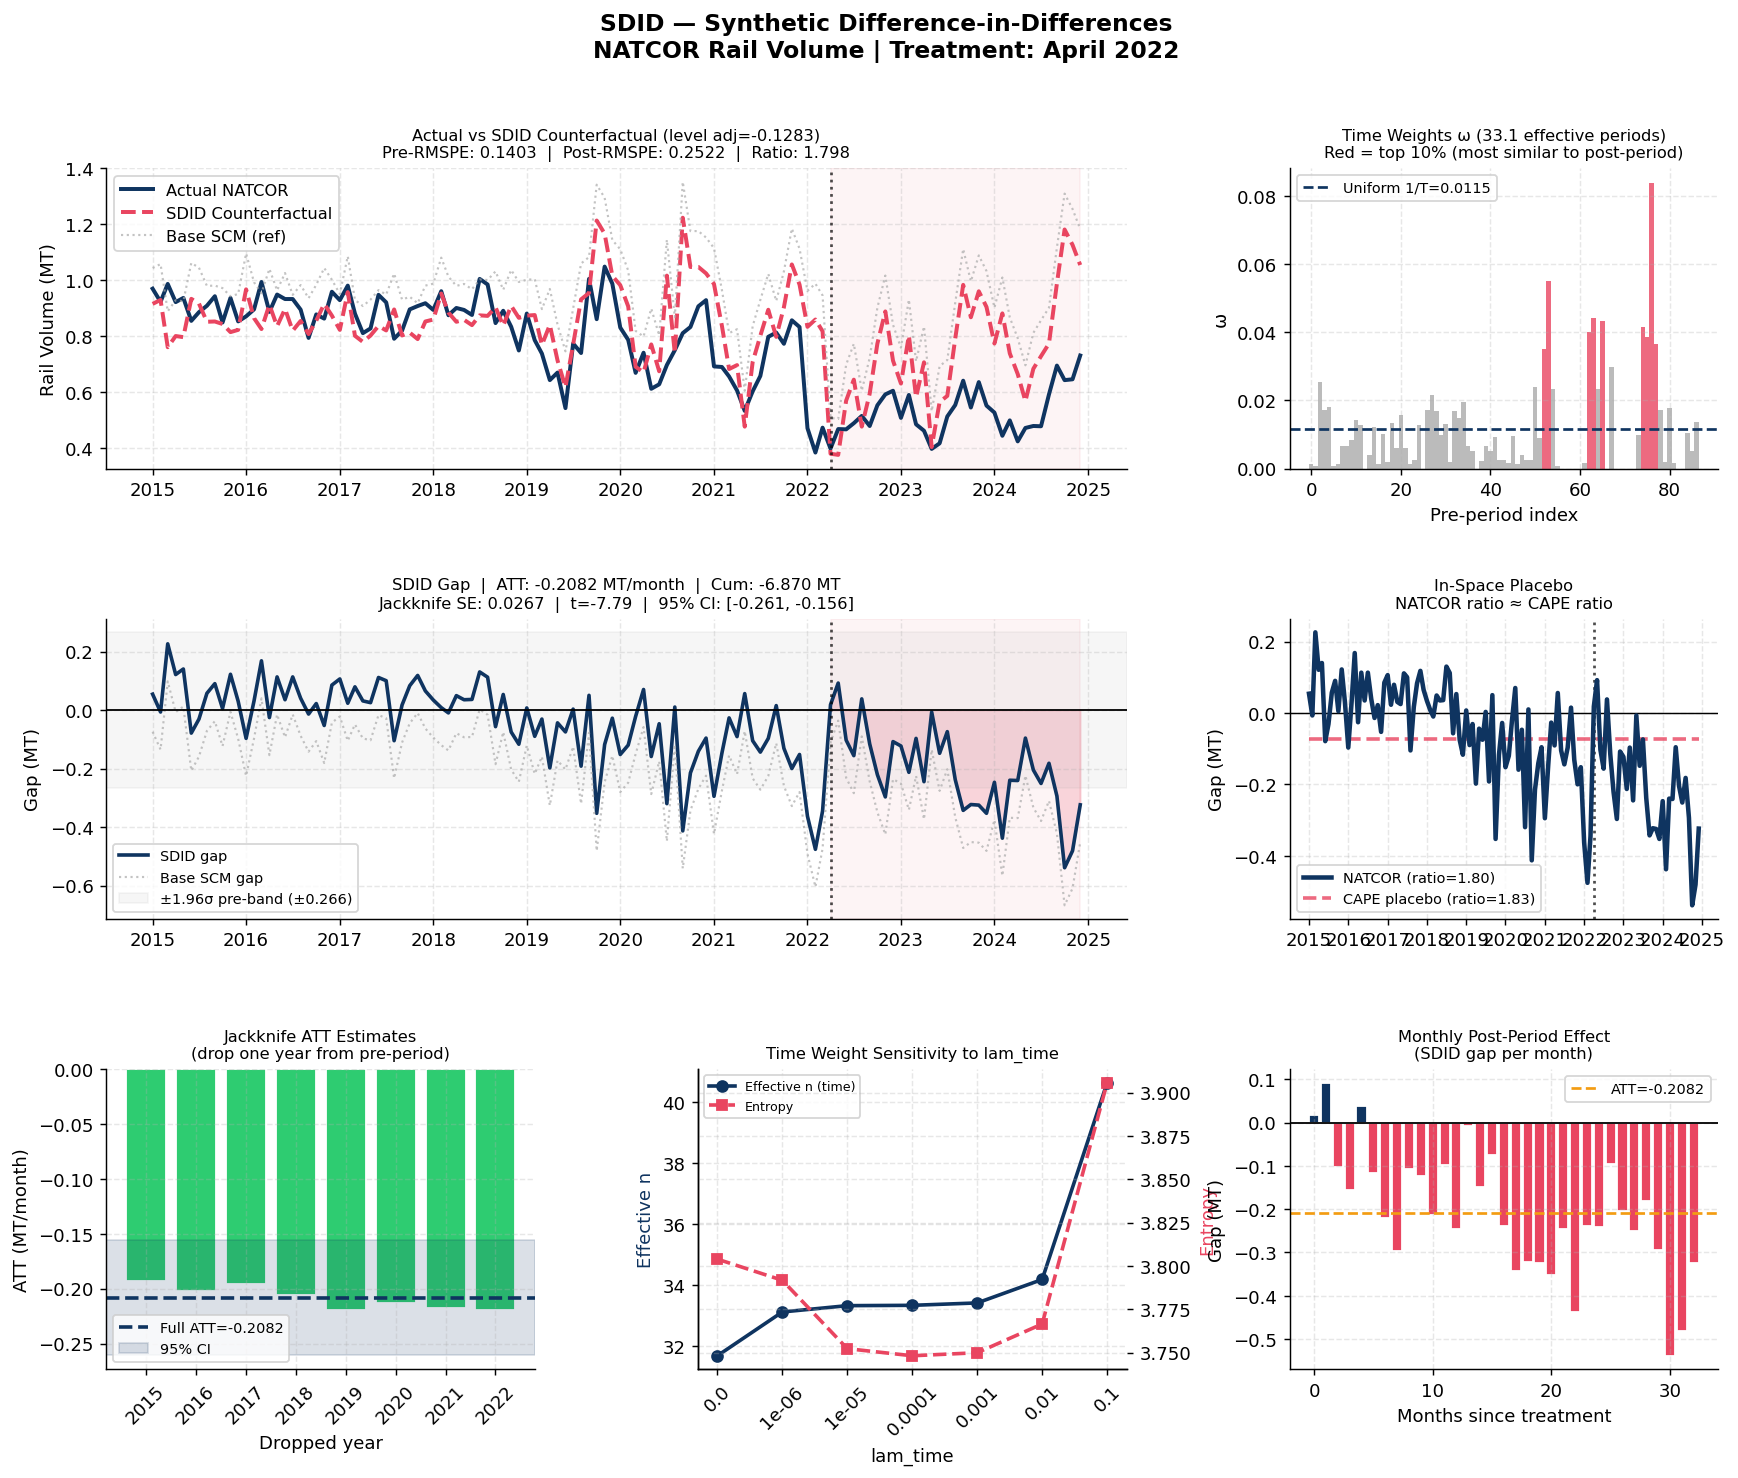

Saved → sdid_fig1_main_panel.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Full diagnostic figure panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.38)

# ── Plot 1: Actual vs SDID counterfactual (full panel) ────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t_stamps, Y_all,        color=BLUE, lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_sdid_all,  color=RED,  lw=2.2, ls='--', label='SDID Counterfactual')
ax1.plot(t_stamps, cf_scm,       color=GREY, lw=1.2, ls=':',  label='Base SCM (ref)', alpha=0.7)
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(f'Actual vs SDID Counterfactual (level adj={level_adj:+.4f})\n'
              f'Pre-RMSPE: {sdid_pre_r:.4f}  |  Post-RMSPE: {sdid_post_r:.4f}  |  Ratio: {sdid_ratio:.3f}',
              fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=9)

# ── Plot 2: Time weights ω ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(range(T_pre), omega,
        color=[RED if w > np.percentile(omega, 90) else GREY for w in omega],
        width=1.0, edgecolor='none', alpha=0.8)
ax2.axhline(1/T_pre, color=BLUE, lw=1.5, ls='--', label=f'Uniform 1/T={1/T_pre:.4f}')
ax2.set_title(f'Time Weights ω ({effective_n(omega):.1f} effective periods)\n'
              f'Red = top 10% (most similar to post-period)', fontsize=9)
ax2.set_xlabel('Pre-period index')
ax2.set_ylabel('ω')
ax2.legend(fontsize=8)

# ── Plot 3: SDID gap ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(t_stamps, gap_sdid, color=BLUE, lw=2, label='SDID gap')
ax3.plot(t_stamps, Y_all - cf_scm, color=GREY, lw=1.2, ls=':', alpha=0.7, label='Base SCM gap')
ax3.axhline(0, color='black', lw=1)
ax3.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax3.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax3.fill_between(t_stamps, gap_sdid, 0, where=(wide.index >= TREAT_START),
                 alpha=0.18, color=RED if sdid_cum < 0 else BLUE)
ci_pre = 1.96 * gap_sdid[:T_pre].std()
ax3.axhspan(-ci_pre, ci_pre, alpha=0.10, color=GREY, label=f'±1.96σ pre-band (±{ci_pre:.3f})')
ax3.set_title(f'SDID Gap  |  ATT: {tau_sdid:.4f} MT/month  |  Cum: {sdid_cum:.3f} MT\n'
              f'Jackknife SE: {jk_se:.4f}  |  t={t_stat:.2f}  |  95% CI: [{ci95_lo:.3f}, {ci95_hi:.3f}]',
              fontsize=9)
ax3.set_ylabel('Gap (MT)')
ax3.legend(fontsize=8)

# ── Plot 4: In-space placebo comparison ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
cf_sp_full = wide[donors[0]].values + level_adj_sp
gap_sp_full = wide[donors[0]].values - cf_sp_full
ax4.plot(t_stamps, gap_sdid,   color=BLUE, lw=2.5, label=f'NATCOR (ratio={sdid_ratio:.2f})', zorder=3)
ax4.plot(t_stamps, gap_sp_full, color=RED,  lw=2, ls='--', alpha=0.8,
         label=f'CAPE placebo (ratio={sp_ratio:.2f})')
ax4.axhline(0, color='black', lw=0.8)
ax4.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax4.set_title(f'In-Space Placebo\nNATCOR ratio {">>" if sdid_ratio > sp_ratio else "≈"} CAPE ratio', fontsize=9)
ax4.set_ylabel('Gap (MT)')
ax4.legend(fontsize=8)

# ── Plot 5: Jackknife ATTs ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
if len(jk_df) > 0:
    bar_c = [GREEN if abs(v - tau_sdid) < jk_se else RED for v in jk_df['ATT']]
    ax5.bar(jk_df['Drop year'].astype(str), jk_df['ATT'], color=bar_c, edgecolor='white')
    ax5.axhline(tau_sdid, color=BLUE, lw=2, ls='--', label=f'Full ATT={tau_sdid:.4f}')
    ax5.axhspan(ci95_lo, ci95_hi, alpha=0.15, color=BLUE, label='95% CI')
    ax5.set_title('Jackknife ATT Estimates\n(drop one year from pre-period)', fontsize=9)
    ax5.set_ylabel('ATT (MT/month)'); ax5.set_xlabel('Dropped year')
    ax5.legend(fontsize=8); ax5.tick_params(axis='x', rotation=45)

# ── Plot 6: ω time-weight sensitivity ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
lam_labels = [str(l) for l in lam_time_grid]
eff_ns_plot = [effective_n(omega_results[l]) for l in lam_time_grid]
entropies   = [entropy(omega_results[l]) for l in lam_time_grid]
ax6.plot(lam_labels, eff_ns_plot, color=BLUE, lw=2, marker='o', ms=6, label='Effective n (time)')
ax6b = ax6.twinx()
ax6b.plot(lam_labels, entropies, color=RED, lw=2, marker='s', ms=6, ls='--', label='Entropy')
ax6.set_title('Time Weight Sensitivity to lam_time', fontsize=9)
ax6.set_xlabel('lam_time'); ax6.set_ylabel('Effective n', color=BLUE)
ax6b.set_ylabel('Entropy', color=RED)
ax6.tick_params(axis='x', rotation=45)
lines1, labs1 = ax6.get_legend_handles_labels()
lines2, labs2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, labs1+labs2, fontsize=7)

# ── Plot 7: Monthly post-period effect bars ────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
post_gaps = gap_sdid[T_pre:]
rel_m = np.arange(T_post)
bar_c7 = [RED if v < 0 else BLUE for v in post_gaps]
ax7.bar(rel_m, post_gaps, color=bar_c7, edgecolor='white', width=0.85)
ax7.axhline(0, color='black', lw=1)
ax7.axhline(tau_sdid, color=AMBER, lw=1.5, ls='--', label=f'ATT={tau_sdid:.4f}')
ax7.set_title('Monthly Post-Period Effect\n(SDID gap per month)', fontsize=9)
ax7.set_xlabel('Months since treatment'); ax7.set_ylabel('Gap (MT)')
ax7.legend(fontsize=8)

fig.suptitle('SDID — Synthetic Difference-in-Differences\nNATCOR Rail Volume | Treatment: April 2022',
             fontsize=13, fontweight='bold')
plt.savefig('sdid_fig1_main_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sdid_fig1_main_panel.png")


## Final Summary Table & Full Method Comparison

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table & Full 4-Method Comparison
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("SDID — FINAL RESULTS SUMMARY")
print("═" * 70)
rows_sdid = [
    ("Method",                     "Value",             "Interpretation"),
    ("─"*28,                       "─"*18,              "─"*28),
    ("lam_time",                   str(LAM_TIME_DEFAULT),"Regularisation for ω (near-zero)"),
    ("Unit weight λ_CAPE",         f"{lam_unit[0]:.6f}", "Full weight on only donor"),
    ("Level adjustment",           f"{level_adj:+.6f} MT","ω-weighted intercept shift"),
    ("Effective time periods",     f"{effective_n(omega):.2f} / {T_pre}","How many pre-periods drive ω"),
    ("ω entropy",                  f"{entropy(omega):.4f}","0=concentrated, ln(T)=uniform"),
    ("",                           "",                  ""),
    ("Pre-period RMSPE",           f"{sdid_pre_r:.6f}", "Fit quality (lower=better)"),
    ("Post-period RMSPE",          f"{sdid_post_r:.6f}","Divergence post-treatment"),
    ("Post/Pre ratio",             f"{sdid_ratio:.4f}",  ">1 = post divergence > noise"),
    ("",                           "",                  ""),
    ("ATT (monthly)",              f"{tau_sdid:+.6f} MT/month","SDID scalar estimate"),
    ("Cumulative effect",          f"{sdid_cum:.4f} MT","33-month total"),
    ("Avg monthly effect",         f"{sdid_avg:.4f} MT","Per-month (≈ATT)"),
    ("Post MAPE",                  f"{sdid_mape:.2f}%", "Prediction accuracy"),
    ("",                           "",                  ""),
    ("Jackknife SE",               f"{jk_se:.6f}",      "Variance from LOO jackknife"),
    ("t-statistic",                f"{t_stat:.3f}",      "|t|>1.96 → significant"),
    ("95% CI (ATT, monthly)",      f"[{ci95_lo:.4f}, {ci95_hi:.4f}]","Jackknife-based CI"),
    ("95% CI (cumulative)",        f"[{ci95_lo*T_post:.3f}, {ci95_hi*T_post:.3f}]","Scaled to 33 months"),
    ("Significant at 95%",         str(abs(t_stat) > 1.96),""),
    ("",                           "",                  ""),
    ("In-space placebo ratio",     f"{sp_ratio:.4f}",   "CAPE pseudo-treated ratio"),
    ("NATCOR > placebo",           str(sdid_ratio > sp_ratio),"Supports causal claim"),
]
for r in rows_sdid:
    print(f"  {r[0]:<30} {r[1]:<20} {r[2]}")

print()
print("═" * 80)
print("ALL 4 ADVANCED METHODS — COMPARISON TABLE")
print("═" * 80)
print(f"{'Metric':<32} {'Base SCM':>10} {'ASCM':>10} {'EN-SCM':>10} {'MC-SCM':>10} {'SDID':>10}")
print("─" * 82)
comparison_rows = [
    ("Pre-RMSPE",            f"{base_pre_r:.4f}",  "see NB",  "see NB",  "see NB",  f"{sdid_pre_r:.4f}"),
    ("Post-RMSPE",           f"{base_post_r:.4f}", "see NB",  "see NB",  "see NB",  f"{sdid_post_r:.4f}"),
    ("Post/Pre Ratio",       f"{base_ratio:.4f}",  "see NB",  "see NB",  "see NB",  f"{sdid_ratio:.4f}"),
    ("Cum effect (MT)",      f"{base_cum:.4f}",    "see NB",  "see NB",  "see NB",  f"{sdid_cum:.4f}"),
    ("ATT monthly",          "N/A",                "N/A",     "N/A",     "N/A",     f"{tau_sdid:.4f}"),
    ("Has CI",               "No",                 "No",      "No",      "Bootstrap","Jackknife"),
    ("Ratio > 1",            str(base_ratio>1),    "see NB",  "see NB",  "see NB",  str(sdid_ratio>1)),
]
for r in comparison_rows:
    print(f"  {r[0]:<30} {r[1]:>10} {r[2]:>10} {r[3]:>10} {r[4]:>10} {r[5]:>10}")
print("═" * 80)
print()
print("Run all 4 advanced notebooks together and compare the 'Cum effect' and 'Ratio' rows.")
print("Consistent direction across methods = stronger evidence of a real treatment effect.")


══════════════════════════════════════════════════════════════════════
SDID — FINAL RESULTS SUMMARY
══════════════════════════════════════════════════════════════════════
  Method                         Value                Interpretation
  ────────────────────────────   ──────────────────   ────────────────────────────
  lam_time                       1e-06                Regularisation for ω (near-zero)
  Unit weight λ_CAPE             1.000000             Full weight on only donor
  Level adjustment               -0.128289 MT         ω-weighted intercept shift
  Effective time periods         33.12 / 87           How many pre-periods drive ω
  ω entropy                      3.7918               0=concentrated, ln(T)=uniform
                                                      
  Pre-period RMSPE               0.140263             Fit quality (lower=better)
  Post-period RMSPE              0.252189             Divergence post-treatment
  Post/Pre ratio                 1.7980       